# Introduction

The *Real or Not? NLP with Disaster Tweets* competitions offers a neat opportunity to see how different approaches to natural language processing work when compared to one another. In this notebook, we'll look at how to start examining NLP data and performing some rudimentary second-order feature engineering. Here's a breakdown of what this notebook covers:

1. Perform an initial exploration of some simple fields.
2. Clean and normalize the data set.
3. Extract first-order features and examine how useful they are.
4. Perform rudimentary natural language processing on the text field.
5. Evaluate our natural language model.
6. Use the model and make predictions that we can submit to the competition.

# 1. Importing the Data

The first step in the process is to import our training data so we can see what kinds of information we have to work with. For this project, we'll start by importing the entire training dataset into a single Pandas dataframe.

In [1]:
import time
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../input/nlp-getting-started/train.csv")
display(train)

test = pd.read_csv("../input/nlp-getting-started/test.csv")
display(test)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


It looks like we need to do a little cleanup here. Both `keyword` and `location` fields are meant to be interpreted as strings. While we're at it, we should probably convert them all to lowercase for ease of processing. We'll also fill all missing values (`<NA>` values) in `keyword` and `location` with the empty string. If we look at the `keyword` strings, we find that some entries have `%20` instead of a space. We should also stem the `keyword` field so we can collapse similar keywords into a single keyword (for example, `death` and `deaths` would become `death`). Let's go ahead and make those changes to the dataframe. 

In [2]:
from gensim.parsing.preprocessing import stem_text

def clean_location_keyword(df):
    df["location"] = df["location"].astype("string").str.lower()
    df["location"].fillna("", inplace=True)
    df["keyword"] = df["keyword"].astype("string").str.lower()
    df["keyword"].replace(regex=r"\%20", value=" ", inplace=True)
    df["keyword"].fillna("", inplace=True)
    df["keyword"] = df["keyword"].apply(stem_text)

clean_location_keyword(train)
clean_location_keyword(test)
train

,id,keyword,location,text,target
0,1,,,Our Deeds are the Reason of this #earthquake M...,1
1,4,,,Forest fire near La Ronge Sask. Canada,1
2,5,,,All residents asked to 'shelter in place' are ...,1
3,6,,,"13,000 people receive #wildfires evacuation or...",1
4,7,,,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,,,Two giant cranes holding a bridge collapse int...,1
7609,10870,,,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,,,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,,,Police investigating after an e-bike collided ...,1


# 2. Looking at Class Imbalance

It looks like we have 7,613 training samples. Let's see how many tweets we have that are examples of disaster versus those that are not. What we're looking at is whether or not we have a balance between samples that are both real examples of disasters, and those that are not.

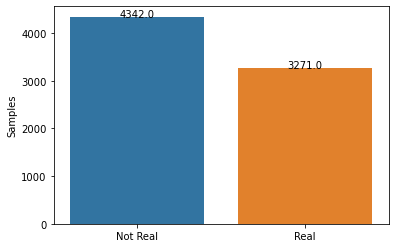

In [3]:
counts = pd.DataFrame(train["target"].value_counts())
counts.rename(columns={"target": "Samples"}, index={0: "Not Real", 1: "Real"}, inplace=True)
ax = sns.barplot(x=counts.index, y=counts.Samples)
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x()+(p.get_width()/2),
        y=height,
        s=round(height),
        ha="center"
    )

For this particular set of data, it looks like we have a slightly skewed distribution between the two classes. In this instance, we'll have to be careful with any machine learning algorithm we use, since we have more tweets that do not pertain to disasters than we do that contain real disasters. 

# 3. Looking at Keywords

Let's take a closer look at what kind of information we have in the `keyword` field, grouped by whether their target is real `1` or not real `0`. Let's just take a look at the first 50 rows or so.

In [4]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(pd.DataFrame(data=train[["id", "keyword", "target"]].groupby(["keyword", "target"]).count()).rename(columns={"id": "count"}).head(50))

count
keyword       target       
              0          19
              1          42
ablaz         0          23
              1          13
accid         0          11
              1          24
aftershock    0          34
airplan accid 0           5
              1          30
ambul         0          18
              1          20
annihil       0          42
              1          21
apocalyps     0          23
              1           9
armageddon    0          37
              1           5
armi          0          29
              1           5
arson         0          10
              1          22
arsonist      0          26
              1           8
attack        0          25
              1          46
avalanch      0          26
              1           4
battl         0          21
              1           5
bioterror     0          24
              1          43
blaze         0          66
              1           6
bleed         0          30
              1           5
blew up       0          31
              1           2
blight        0          30
              1           2
blizzard      0          33
              1           4
blood         0          30
              1           5
bloodi        0          32
              1           3
blown up      0          28
              1           5
bodi bag      0         100
              1           7
bomb          0          40

We can see that there are certain keywords that are strongly tied to one class. For example, `airplan accid` is very strongly associated with the real disaster target - we see it appear 35 times, and 30 of those times it is a real disaster, while only 5 times it is not. This is good news, since it suggests there are likely keywords here that will provide separation between classes.

Once last thing we will have to do with the keywords is categorize them. Most machine learning algorithms expect categorical data to be in the form of an integer. We'll convert the keyword into a category type, and save the category code as a new column, and use that for our machine learning technique.

In [5]:
train["keyword"] = train["keyword"].astype("category")
train["keyword_cat"] = train["keyword"].cat.codes
test["keyword_cat"] = test["keyword"].apply(lambda x: train["keyword"].cat.categories.get_loc(x) if x in train["keyword"].cat.categories.to_list() else 0)

train

,id,keyword,location,text,target,keyword_cat
0,1,,,Our Deeds are the Reason of this #earthquake M...,1,0
1,4,,,Forest fire near La Ronge Sask. Canada,1,0
2,5,,,All residents asked to 'shelter in place' are ...,1,0
3,6,,,"13,000 people receive #wildfires evacuation or...",1,0
4,7,,,Just got sent this photo from Ruby #Alaska as ...,1,0
...,...,...,...,...,...,...
7608,10869,,,Two giant cranes holding a bridge collapse int...,1,0
7609,10870,,,@aria_ahrary @TheTawniest The out of control w...,1,0
7610,10871,,,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1,0
7611,10872,,,Police investigating after an e-bike collided ...,1,0


# 4. Looking at Location

Let's take look at the first 100 entries in the location field and see what we're working with.

In [6]:
print([location for location in train["location"]][:100])

['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', 'birmingham', 'est. september 2012 - bristol', 'africa', 'philadelphia, pa', 'london, uk', 'pretoria', 'world wide!!', '', 'paranaque city', 'live on webcam', '', 'milky way', '', '', '', 'greensboro,north carolina', '', 'live on webcam', 'england.', 'sheffield township, ohio', 'india', 'barbados', 'anaheim', 'abuja', 'usa', 'south africa', 'sao paulo, brazil', 'hollywoodland ', 'edmonton, alberta - treaty 6', '', 'inang pamantasan', 'twitter lockout in progress', 'concord, ca', 'calgary, ab', 'birmingham', 'san francisco', 'clvlnd', 'nashville, tn', 'santa clara, ca', 'uk', 'st. louis, mo', 'walker county, alabama', 'australia', 'north carolina', '', 'norf carolina', 'san mateo county, ca', 'north carolina', 'njoro, kenya', '', "your sister's bedroom", '', 'arlington, tx', 'south bloomfield, oh', '', 'new hanover county, nc', 'maldives', 'manchester, nh', 'wilmi

In some instances we have countries, others include states, and some include cities. Yet others include junk data such as `global` as well as `Twitter Lockout in progress`. We'll need a way to clean and normalize this data so that it's a little more useful to us. Normalizing this data may turn out to be beneficial, but based on how messy the field is, it may not be worthwhile to spend huge amounts of time trying to clean it. As it stands, let's see if we can use the Python package `pycountry` to help us sort out some of this data.

In [7]:
from pycountry import subdivisions

def clean_state_country(df):
    subs = [subdivision.name.lower() for subdivision in subdivisions]
    countries = [subdivision.country_code for subdivision in subdivisions]
    country = []
    state = []
    for _, row in df.iterrows():
        match_found = False
        location_lower = row["location"].lower()
        for index, subdivision in enumerate(subs):
            if subdivision in location_lower:
                country.append(countries[index])
                state.append(subdivision)
                match_found = True
                break
        if not match_found:
            country.append("")
            state.append("")
    df["country"] = country
    df["state"] = state
    
clean_state_country(train)
clean_state_country(test)

train["country"] = train["country"].astype("category")
train["country_cat"] = train["country"].cat.codes
train["state"] = train["state"].astype("category")
train["state_cat"] = train["state"].cat.codes

# Apply the same category codes to the testing dataset
test["state_cat"] = test["state"].apply(lambda x: train["state"].cat.categories.get_loc(x) if x in train["state"].cat.categories.to_list() else 0)
test["country_cat"] = test["country"].apply(lambda x: train["country"].cat.categories.get_loc(x) if x in train["country"].cat.categories.to_list() else 0)

Now that we have country and state information, we should be able to look at those fields the same way we examined keywords. Let's take a look what happens.

In [8]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(pd.DataFrame(data=train[["id", "country", "target"]].groupby(["country", "target"]).count()).rename(columns={"id": "count"}).head(50))

count
country target        
        0       3071.0
        1       2282.0
AG      0          1.0
        1          1.0
AL      0          7.0
        1         13.0
AM      0          1.0
        1          NaN
AR      0          6.0
        1          4.0
AU      0         14.0
        1         18.0
BD      0          NaN
        1          2.0
BF      0         77.0
        1         55.0
BG      0          2.0
        1          2.0
BR      0          5.0
        1          1.0
BS      0          3.0
        1          1.0
BT      0        136.0
        1        116.0
BW      0         11.0
        1          8.0
BZ      0          2.0
        1          NaN
CA      0         29.0
        1         29.0
CG      0          4.0
        1          4.0
CH      0          7.0
        1          3.0
CM      0         63.0
        1         44.0
CO      0          2.0
        1          NaN
CV      0         16.0
        1         12.0
CZ      0          3.0
        1          NaN
DE      0          1.0
        1          5.0
DJ      0          2.0
        1          5.0
DO      0          NaN
        1          3.0
DZ      0          2.0
        1          6.0

There are quite a number of entries for which we have no country information. The first row shows us the empty string, which is the number of rows without country information. The total is 5,353 entries, which is more than half of our available training data. For entries with countries, we're seeing somewhat equal splits between real and not real disasters. This is to be expected, as people geotag tweets from all countries whether or not they are actually disasters. It's unlikely that real disasters would exclusively be geotagged. This is probably the same for state information. Let's take a look.

In [9]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(pd.DataFrame(data=train[["id", "state", "target"]].groupby(["state", "target"]).count()).rename(columns={"id": "count"}).head(50))

count
state                        target        
                             0       3071.0
                             1       2282.0
aberdeenshire                0          1.0
                             1          NaN
abia                         0          4.0
                             1          1.0
ailuk                        0          NaN
                             1          1.0
ain                          0         19.0
                             1         25.0
aklan                        0          5.0
                             1          5.0
akwa ibom                    0          1.0
                             1          NaN
alaska                       0          2.0
                             1          2.0
alba                         0          1.0
                             1          NaN
alberta                      0          5.0
                             1         13.0
alger                        0          NaN
                             1          1.0
alicante                     0          1.0
                             1          1.0
ankara                       0          NaN
                             1          1.0
antioquia                    0          1.0
                             1          NaN
arad                         0          2.0
                             1          2.0
ariana                       0          2.0
                             1          NaN
arizona                      0          4.0
                             1          5.0
arkansas                     0          1.0
                             1          5.0
arta                         0          2.0
                             1          5.0
assam                        0          NaN
                             1          1.0
asti                         0          1.0
                             1          1.0
auckland                     0          3.0
                             1          1.0
aude                         0          NaN
                             1          1.0
aur                          0          2.0
                             1          1.0
australian capital territory 0          NaN
                             1          2.0

As predicted, we're missing the same amount of state information. Looking at the low counts for each state, we're probably not going to get very useful information from this field, but we'll keep it intact for now.

# 5. Simple Feature Engineering

Before we look directly at the text as a feature, let's think about some of the other first-order information we can extract from it. Here are a few features that may be informative:

* Total length of the text
* Average word length
* Number of `@` mentions
* Number of hashtags
* Number of numeric values in the text (excluding timestamps)
* Number of URLs in the text
* Number of timestamps in the text

Let's go ahead and extract these fields.

In [10]:
import re

def engineer_features(df):
    df["total_length"] = df["text"].apply(len)
    df["avg_word_length"] = df["text"].apply(lambda x: round(sum(len(word) for word in x.split()) / len(x.split())))
    df["num_ats"] = df["text"].apply(lambda x: x.count("@"))
    df["num_hashtags"] = df["text"].apply(lambda x: x.count("#"))
    df["num_numeric"] = df["text"].apply(lambda x: len(re.findall(r"\w[0-9,]+\w", x)))
    df["num_urls"] = df["text"].apply(lambda x: x.count("http"))
    df["num_timestamps"] = df["text"].apply(lambda x: len(re.findall(r"[0-9]+:[0-9]+", x)))

engineer_features(train)
engineer_features(test)
train

,id,keyword,location,text,target,keyword_cat,country,state,country_cat,state_cat,total_length,avg_word_length,num_ats,num_hashtags,num_numeric,num_urls,num_timestamps
0,1,,,Our Deeds are the Reason of this #earthquake M...,1,0,,,0,0,69,4,0,1,0,0,0
1,4,,,Forest fire near La Ronge Sask. Canada,1,0,,,0,0,38,5,0,0,0,0,0
2,5,,,All residents asked to 'shelter in place' are ...,1,0,,,0,0,133,5,0,0,0,0,0
3,6,,,"13,000 people receive #wildfires evacuation or...",1,0,,,0,0,65,7,0,1,1,0,0
4,7,,,Just got sent this photo from Ruby #Alaska as ...,1,0,,,0,0,88,4,0,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7608,10869,,,Two giant cranes holding a bridge collapse int...,1,0,,,0,0,83,7,0,0,0,1,0
7609,10870,,,@aria_ahrary @TheTawniest The out of control w...,1,0,,,0,0,125,5,2,0,0,0,0
7610,10871,,,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1,0,,,0,0,65,7,0,0,1,1,1
7611,10872,,,Police investigating after an e-bike collided ...,1,0,,,0,0,137,6,0,0,0,0,0


# 6. Pre-processing Text

For our textual analysis to be useful, we'll have to perform some pre-processing on the text first to make it easier to work with. Here's what we're going to do:

* Remove words that don't have any value, such as `the`, `of`, `and` (stopword removal)
* We're going to strip out any links since they are `tco` encoded for Twitter
* We'll remove all punctuation
* We'll remove the numerics
* We'll remove multiple whitespaces

For now we're not going to stem the text. Stemming is meant to collapse multiple morphological variants of the same word into a single stem (for example `dance`, `dancing`, `dances` could collapse to `danc`). We're not going to do that yet.

In [11]:
from gensim.parsing.preprocessing import remove_stopwords, strip_punctuation, strip_multiple_whitespaces, strip_numeric

def normalize_text(df):
    normalized_text = []

    for _, row in df.iterrows():
        new_text = remove_stopwords(row["text"].lower())
        new_text = re.sub(r"http\S+", "", new_text)
        new_text = strip_punctuation(new_text)
        new_text = strip_numeric(new_text)
        new_text = strip_multiple_whitespaces(new_text)
        normalized_text.append(new_text.strip())

    df["normalized_text"] = normalized_text

normalize_text(train)
normalize_text(test)
train

,id,keyword,location,text,target,keyword_cat,country,state,country_cat,state_cat,total_length,avg_word_length,num_ats,num_hashtags,num_numeric,num_urls,num_timestamps,normalized_text
0,1,,,Our Deeds are the Reason of this #earthquake M...,1,0,,,0,0,69,4,0,1,0,0,0,deeds reason earthquake allah forgive
1,4,,,Forest fire near La Ronge Sask. Canada,1,0,,,0,0,38,5,0,0,0,0,0,forest near la ronge sask canada
2,5,,,All residents asked to 'shelter in place' are ...,1,0,,,0,0,133,5,0,0,0,0,0,residents asked shelter place notified officer...
3,6,,,"13,000 people receive #wildfires evacuation or...",1,0,,,0,0,65,7,0,1,1,0,0,people receive wildfires evacuation orders cal...
4,7,,,Just got sent this photo from Ruby #Alaska as ...,1,0,,,0,0,88,4,0,2,0,0,0,got sent photo ruby alaska smoke wildfires pou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7608,10869,,,Two giant cranes holding a bridge collapse int...,1,0,,,0,0,83,7,0,0,0,1,0,giant cranes holding bridge collapse nearby homes
7609,10870,,,@aria_ahrary @TheTawniest The out of control w...,1,0,,,0,0,125,5,2,0,0,0,0,aria ahrary thetawniest control wild fires cal...
7610,10871,,,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1,0,,,0,0,65,7,0,0,1,1,1,m utc km s volcano hawaii
7611,10872,,,Police investigating after an e-bike collided ...,1,0,,,0,0,137,6,0,0,0,0,0,police investigating e bike collided car littl...


# 7. Training and Validating the Classifier

Now it's time to acutally build a classifier and see how well it does. To evaluate how well our features are working, we're going to split up our training data into a training set and a validation set. We'll do this 5 times for a 5-fold cross validation. Our difference between sets gives us an idea how robust our model actually is to variations in training data. To handle our textual data, we're going to treat it as a bag-of-words and use a regression model. To represent the words, we'll use a TF/IDF vector (term frequency / inverse document frequency). Once we build the regressor, we'll use that to make predictions, and use the predicted outputs, along with our other features in a light GBM model to make actual predictions on the test data. 

In [12]:
import gc

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDRegressor

vectorizer = TfidfVectorizer()
skf = StratifiedKFold(n_splits=5, random_state=2020, shuffle=True)

features = [
    "keyword_cat", "country_cat", "state_cat", "total_length", "avg_word_length", 
    "num_ats", "num_hashtags", "num_numeric", "num_urls", "num_timestamps"
]

params = {
    "learning_rate": 0.01, 
    "verbose": 100, 
    "random_state": 2020, 
    "metric": "average_precision", 
    "verbose": -1,
    "boosting_type": "dart",
    "num_leaves": 20,
    "num_iterations": 200,
    "cat_column": "0,1,2", # array features 0, 1, and 2 are categorical
}

importances = pd.DataFrame()
best_score = 0.0
best_model = None
best_sgd = None

for fold, (train_index, test_index) in enumerate(skf.split(train, train["target"])):
    print("-------> fold {} <--------".format(fold + 1))
    print(": Build regression model")
    x_train, x_valid = pd.DataFrame(train.iloc[train_index]), pd.DataFrame(train.iloc[test_index])
    y_train, y_valid = train["target"].iloc[train_index], train["target"].iloc[test_index]
    
    x_train_tfidf = vectorizer.fit_transform(x_train["normalized_text"]).astype(np.float32)
    x_valid_tfidf = vectorizer.transform(x_valid["normalized_text"]).astype(np.float32)
    
    sgd_classifier = SGDRegressor(alpha=0.001, penalty="l2", loss="squared_epsilon_insensitive", random_state=2020)
    sgd_classifier.fit(x_train_tfidf, y_train)
    
    x_train_features = pd.DataFrame(x_train[features])
    x_train_features["sgd_score"] = sgd_classifier.predict(x_train_tfidf)
    x_valid_features = pd.DataFrame(x_valid[features])
    x_valid_features["sgd_score"] = sgd_classifier.predict(x_valid_tfidf)
    
    print(": Build GBM model")
    model = lgb.LGBMClassifier(
        **params,
    )
    model.fit(
        x_train_features, 
        y_train,
        eval_set=[(x_valid_features, y_valid)],
        verbose=100,
    )

    train_predictions = model.predict(x_valid_features)
    
    imp_df = pd.DataFrame()
    imp_df['feature'] = x_valid_features.columns
    imp_df['gain'] = model.booster_.feature_importance(importance_type='gain')
    imp_df['fold'] = fold + 1
    importances = pd.concat([importances, imp_df], axis=0, sort=False)
    print(classification_report(y_valid, train_predictions, target_names=["Not Real", "Real"]))
    score = model.score(x_valid_features, y_valid)
    if score > best_score:
        print("--> This model is the best so far {:0.5}".format(score))
        best_model = model
        best_score = score
        best_sgd = sgd_classifier
        # Best is 0.79448 - alpha=0.001, loss=squared_epsilon_insensitive, penalty=l2 (lgbm boosting=dart, learning_rate=0.01, num_leaves=20, num_iterations=200)

-------> fold 1 <--------
: Build regression model
: Build GBM model


/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


              precision    recall  f1-score   support

    Not Real       0.83      0.80      0.81       868
        Real       0.74      0.78      0.76       655

    accuracy                           0.79      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.79      0.79      0.79      1523

--> This model is the best so far 0.79054
-------> fold 2 <--------
: Build regression model
: Build GBM model


/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


              precision    recall  f1-score   support

    Not Real       0.82      0.81      0.82       869
        Real       0.76      0.77      0.76       654

    accuracy                           0.79      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.80      0.79      0.79      1523

--> This model is the best so far 0.79448
-------> fold 3 <--------
: Build regression model
: Build GBM model


/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


              precision    recall  f1-score   support

    Not Real       0.81      0.80      0.80       869
        Real       0.74      0.76      0.75       654

    accuracy                           0.78      1523
   macro avg       0.77      0.78      0.78      1523
weighted avg       0.78      0.78      0.78      1523

-------> fold 4 <--------
: Build regression model
: Build GBM model


/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


              precision    recall  f1-score   support

    Not Real       0.79      0.80      0.80       868
        Real       0.73      0.72      0.73       654

    accuracy                           0.77      1522
   macro avg       0.76      0.76      0.76      1522
weighted avg       0.77      0.77      0.77      1522

-------> fold 5 <--------
: Build regression model
: Build GBM model


/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


              precision    recall  f1-score   support

    Not Real       0.78      0.80      0.79       868
        Real       0.73      0.70      0.71       654

    accuracy                           0.76      1522
   macro avg       0.75      0.75      0.75      1522
weighted avg       0.76      0.76      0.76      1522



# 8. Feature Performance

We can take a look and see how our various features are performing.

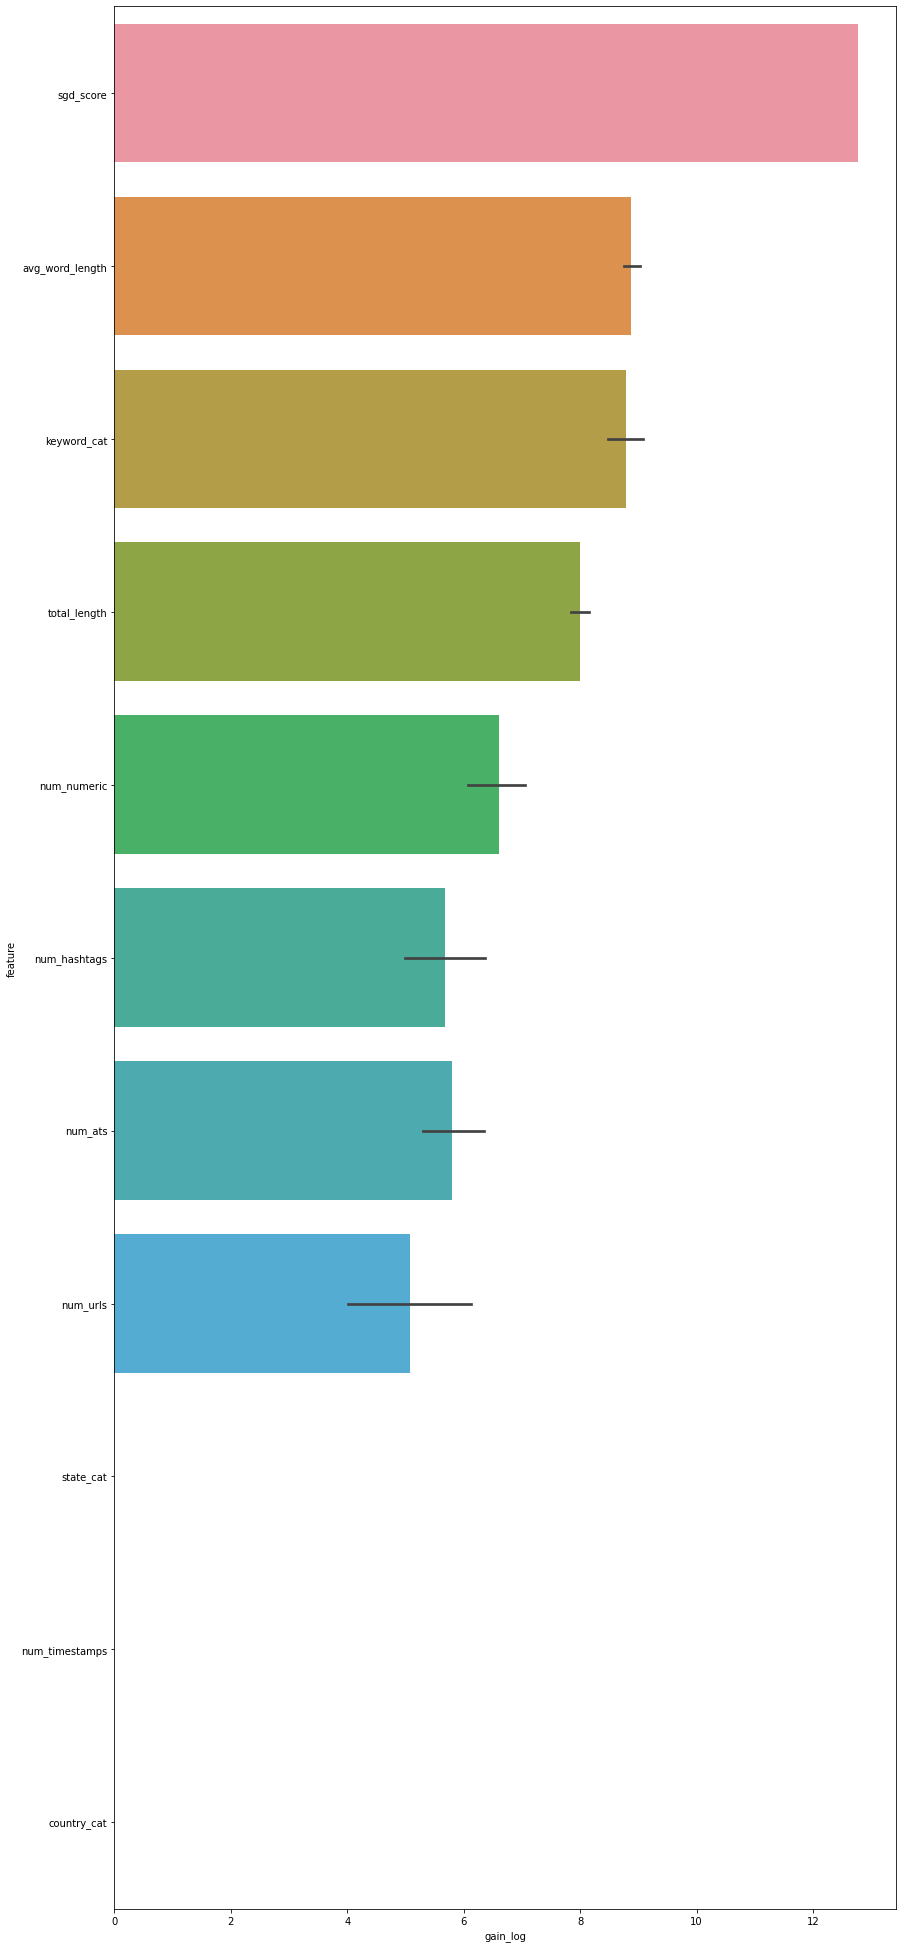

In [13]:
import warnings
warnings.simplefilter('ignore', FutureWarning)

importances['gain_log'] = np.log1p(importances['gain'])
mean_gain = importances[['gain', 'feature']].groupby('feature').mean()
importances['mean_gain'] = importances['feature'].map(mean_gain['gain'])

plt.figure(figsize=(14, 35))
_ = sns.barplot(x='gain_log', y='feature', data=importances.sort_values('mean_gain', ascending=False))

# 9. Building and Submitting the Final Model

Let's go ahead and build a model that uses all of the data, and takes all the features we've examined so far. Once the model is built, we can submit the result.

In [14]:
vectorizer = TfidfVectorizer(binary=True)

features = [
    "keyword_cat", "country_cat", "state_cat", "total_length", "avg_word_length", 
    "num_ats", "num_hashtags", "num_numeric", "num_urls", "num_timestamps"
]

params = {
    "learning_rate": 0.01, 
    "verbose": 100, 
    "random_state": 2020, 
    "metric": "average_precision", 
    "verbose": -1,
    "boosting_type": "dart",
    "num_leaves": 20,
    "num_iterations": 200,
    "cat_column": "0,1,2", # array features 0, 1, and 2 are categorical
}

print(": Build regression model")
train_tfidf = vectorizer.fit_transform(train["normalized_text"]).astype(np.float32)

sgd_classifier = SGDRegressor(alpha=0.001, penalty="l2", loss="squared_epsilon_insensitive", random_state=2020)
sgd_classifier.fit(train_tfidf, train["target"])

train_features = pd.DataFrame(train[features])
train_features["sgd_score"] = sgd_classifier.predict(train_tfidf)

print(": Build GBM model")
model = lgb.LGBMClassifier(
    **params,
)
model.fit(
    train_features, 
    train["target"],
    verbose=100,
)

: Build regression model
: Build GBM model


/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


LGBMClassifier(boosting_type='dart', cat_column='0,1,2', learning_rate=0.01,
               metric='average_precision', num_iterations=200, num_leaves=20,
               random_state=2020, verbose=-1)

Here is the code to run the predictions on the test data, and build the submission file.

In [15]:
test_tfidf = vectorizer.transform(test["normalized_text"]).astype(np.float32)
test_features = pd.DataFrame(test[features])
test_features["sgd_score"] = sgd_classifier.predict(test_tfidf)
predictions = model.predict(test_features)
submission = pd.DataFrame({"id": test["id"], "target": predictions})
submission.to_csv("submission.csv", index=False)